# Question: 
### How does the admission rates of the Colorado School of Mines and MIT compare to other post-secondary education institutes?

## Study:
### This is a census study because it is looking at all post-secondary institutions in the United States.

In [1]:
import pandas
import seaborn as sb
import matplotlib as mb
import numpy as np

In [3]:
college = pandas.read_csv("cleaned_college.csv")

In [21]:
rate = college["admission_rate"]
admission_rate_percent = []
college2 = college.copy()

for i in rate:
    admission_rate_percent.append((i * 100))

college2["admission_rate_percent"] = admission_rate_percent
rate_percent = college2["admission_rate_percent"]

mines = college[college["school_name"] == "Colorado School of Mines"]["admission_rate"].values[0]
mit = college[college["school_name"] == "Massachusetts Institute of Technology"]["admission_rate"].values[0]
mean = rate.mean()
std = rate.std()
zmines = (mines - mean) / std
zmit = (mit - mean) / std
mean_percent = rate.mean() * 100
mines_percent = college[college["school_name"] == "Colorado School of Mines"]["admission_rate"].values[0] * 100
mit_percent = college[college["school_name"] == "Massachusetts Institute of Technology"]["admission_rate"].values[0] * 100
print(mean)
print(mines)
print(mit)
print(zmines)
print(zmit)
print(mean_percent)
print(mines_percent)
print(mit_percent)

0.7275854450261781
0.6069
0.0455
-0.5217992060910758
-2.94908506675131
72.75854450261781
60.69
4.55


Not including all 4363 institutes with open admission.


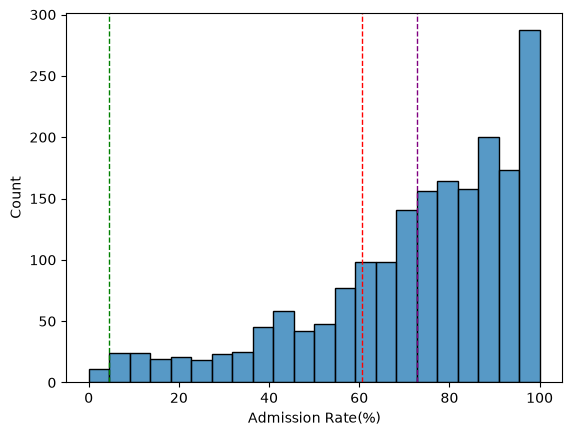

In [22]:
n = 0
for i in admission_rate_percent:
    if(np.isnan(i) == True):
        n+=1

print(f"Not including all {n} institutes with open admission.")
plot = sb.histplot(
    x=rate_percent,
)
mb.pyplot.xlabel("Admission Rate(%)")
plot.axvline(mean_percent, color="purple", linestyle="--", linewidth=1, label=f"mean_percent: {mean_percent:.2f}")
plot.axvline(mines_percent, color="red", linestyle="--", linewidth=1, label=f"mines_percent: {mines_percent:.2f}")
plot.axvline(mit_percent, color="green", linestyle="--", linewidth=1, label=f"mit_percent: {mit_percent:.2f}")

# Conclusion:
### The Colorado School of Mines has a z-score of about -0.5, and MIT has a z-score of about -3.0, so MIT is an outlier and mines is not an outlier.